# **Exercise 2: Text Processing using Python and Google Colab**

Author: John Kevin T. Dela Cruz
Subject/Section: ITC C508 | 401I


# **Install Relevant Libraries**




This code used to import all libraries for implementation of pipelines and mount the google drive where my dataset lives. The `from google.colab import drive` is used to import the drive module.

In [20]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from google.colab import drive
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

drive.mount('/content/drive')


df = pd.read_csv('/content/drive/MyDrive/ITE Elective 4/NLP-Exercise/youtube_comments_cleaned.csv')


df.head()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,CommentID,VideoID,VideoTitle,AuthorName,AuthorChannelID,CommentText,Sentiment,Likes,Replies,PublishedAt,CountryCode,CategoryID
0,UgyRjrEdJIPrf68uND14AaABAg,mcY4M9gjtsI,They killed my friend.#tales #movie #shorts,@OneWhoWandered,UC_-UEXaBL1dqqUPGkDll49A,Anyone know what movie this is?,Neutral,0,2,2025-01-15 00:54:55,NZ,1
1,UgxXxEIySAwnMNw8D7N4AaABAg,2vuXcw9SZbA,Man Utd conceding first penalty at home in yea...,@chiefvon3068,UCZ1LcZESjYqzaQRhjdZJFwg,The fact they're holding each other back while...,Positive,0,0,2025-01-13 23:51:46,AU,17
2,UgxB0jh2Ur41mcXr5IB4AaABAg,papg2tsoFzg,Welcome to Javascript Course,@Abdulla-ip8qr,UCWBK35w5Swy1iF5xIbEyw3A,waiting next video will be?,Neutral,1,0,2020-07-06 13:18:16,IN,27
3,UgwMOh95MfK0GuXLLrF4AaABAg,31KTdfRH6nY,Building web applications in Java with Spring ...,@finnianthehuman,UCwQ2Z03nOcMxWozBb_Cv66w,Thanks for the great video.\n\nI don't underst...,Neutral,0,1,2024-09-18 12:04:12,US,27
4,UgxJuUe5ysG8OSbABAl4AaABAg,-hV6aeyPHPA,After a new engine her car dies on her way hom...,@ryoutubeplaylistb6137,UCTTcJ0tsAKQokmHB2qVb1qQ,Good person helping good people.\nThis is how ...,Positive,3,1,2025-01-10 19:39:03,US,2


# **Pipeline Preprocessing**

Starting with, removing the irrelevant Column in the dataset. Using `df.drop` method. Specifically, it deletes columns such as CommentID, VideoID, VideoTitle, AuthorName, AuthorChannelID, Likes, Replies, PublishedAt, CountryCode, and CategoryID. These columns may contain metadata or information that is not directly relevant to the text analysis or Natural Language Processing (NLP) tasks being performed later.

In [21]:
df = df.drop(columns=['CommentID', 'VideoID', 'VideoTitle', 'AuthorName', 'AuthorChannelID', 'Likes', 'Replies', 'PublishedAt', 'CountryCode', 'CategoryID']);

After removed all irrelevant Column in the dataset, display remaining columns that are relevant and that can be used for text processing later.

by using `print(df)`

In [22]:
print(df)

                                               CommentText Sentiment
0                          Anyone know what movie this is?   Neutral
1        The fact they're holding each other back while...  Positive
2                              waiting next video will be?   Neutral
3        Thanks for the great video.\n\nI don't underst...   Neutral
4        Good person helping good people.\nThis is how ...  Positive
...                                                    ...       ...
1032220  Any recommendations for how to build on top of...  Positive
1032221            Act foolishly, receive foolish rewards.  Negative
1032222  I think many people would like to know the mod...   Neutral
1032223                                            Caramel   Neutral
1032224                                       Why no rust?   Neutral

[1032225 rows x 2 columns]


The `detect_text_noise` function is designed to analyze a given text input and detect various types of noise typically addressed in text preprocessing for Natural Language Processing (NLP) tasks. It returns a dictionary called noise_report that contains detailed information about the input. Specifically, it checks if the text contains uppercase letters, which may need to be normalized through lowercasing, and uses a regular expression to identify special characters that are not alphanumeric or whitespace, which are often considered irrelevant in NLP.

`original_text`: stores the original or unprocessed text for reference.

`has_uppercase`: identify if there's any upper case by using for loop and `char.isupper()`.

`has_special_chars`: handles special characters in text by using `bool(re.search) and regular experession.

`has_stopwords`: identify irrelevant or uncommon words in input text.

`stopwords_found`: where we stored the value of `has_stopwords` which is the irrelevant text.

'cleaned_text`: Placeholder for the final cleaned version of the text after all noise is removed. This is meant to be filled in later


In [23]:
def detect_text_noise(text):
    noise_report = {
        "original": text,
        "has_uppercase": any(char.isupper() for char in text),
        "has_special_chars": bool(re.search(r"[^a-zA-Z0-9\s]", text)),
        "has_stopwords": False,
        "stopwords_found": [],
        "cleaned_text": ""
    }

## **Pipeline Preprocessing**

The purpose of this code, is to perform text processing pipeline such as lowercasing, special character removal, stopword removal, and tokenization.

The `lowercasing_text` function transforms raw text into a uniform lowercase format, ensuring consistency across the dataset.

Followed by, `special_character_removal` to remove special character such as punctuation marks, emojis, and other special characters from the text by using the `re.sub` from re libraries. To ensure that only meaningful textual content is retained

`stopword_removal`eliminates the irrelevant or uncommon word in the text and retain the imporant ones. Performing this helps the model to focus on meaningful words, leads to improving accuracy.

Lastly, `tokenization` to break down a stream of text into smaller units called tokens, it's essential for guiding machines to accurately understand and process textual data.


In [24]:
nltk.download('punkt')
nltk.download('stopwords')
from collections import Counter

stop_words = set(stopwords.words('english'))

# Pipeline Functions
def lowercasing_text(text):
    print("Before lowercasing:", text, "\n")
    result = text.lower()
    print("After lowercasing:", result, "\n")
    return result

def special_character_removal(text):
    print("Before special character removal:", text, "\n")
    result = re.sub(r"[^a-zA-Z0-9\s]", '', text)
    print("After special character removal:", result, "\n")
    return result

def stopword_removal(text):
    print("Before stopword removal:", text, "\n")
    result_words = []
    for word in text.split():
        if word.strip() not in stop_words:
            result_words.append(word)
        else:
            print("Removed stopword:", word)
    result = ' '.join(result_words)
    print("After stopword removal:", result, "\n")
    return result

def tokenization(text):
    print("Before tokenization:", text, "\n")
    result = word_tokenize(str(text))
    print("After tokenization:", result, "\n")
    return result

raw_text = df['CommentText'][3]


lowercased = lowercasing_text(raw_text)
no_special_chars = special_character_removal(lowercased)
stopwords_removed = stopword_removal(no_special_chars)
tokens = tokenization(stopwords_removed)
cleaned_text = ' '.join(tokens)

df_steps = pd.DataFrame({
    'Original': [raw_text],
    'Lowercased': [lowercased],
    'No Special Chars': [no_special_chars],
    'Stopwords Removed': [stopwords_removed],
    'Tokenized': [tokens],
    'Final Cleaned Text': [cleaned_text]
})

print("\nCLEANING STEPS TABLE:\n")
print(df_steps.T)


def clean_text_pipeline(text):
    lowercased = text.lower()
    no_special_chars = re.sub(r"[^a-zA-Z0-9\s]", '', lowercased)
    result_words = [word for word in no_special_chars.split() if word.strip() not in stop_words]
    tokens = word_tokenize(' '.join(result_words))
    return ' '.join(tokens)


df['CleanedCommentText'] = df['CommentText'].apply(clean_text_pipeline)


Before lowercasing: Thanks for the great video.

I don't understand why the DB continues to be accesible through port 8080 when the local machine connects to the docker container through port 5432? Or, why is it not possible to make GET requests to port 5432 on my local machine?

Is it just because the port 5432 is only the port used to connect the app to the database, but the app itself is still handling HTTP through 8080? So an incoming request hits 8080, then goes through 5432 to get to the database? 

After lowercasing: thanks for the great video.

i don't understand why the db continues to be accesible through port 8080 when the local machine connects to the docker container through port 5432? or, why is it not possible to make get requests to port 5432 on my local machine?

is it just because the port 5432 is only the port used to connect the app to the database, but the app itself is still handling http through 8080? so an incoming request hits 8080, then goes through 5432 to ge

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


The `summarize_text_stats` function is used to generate and compute statistical summaries of a list of texts. It helps in comparing key metrics of a textual dataset before and after preprocessing, such as total documents, total and unique word counts, average words per document, and the top 10 most frequent words.

In [25]:
def summarize_text_stats(texts):
    all_words = " ".join(texts).split()
    stats = {
        'total_documents': len(texts),
        'total_words': len(all_words),
        'unique_words': len(set(all_words)),
        'avg_words_per_doc': sum(len(doc.split()) for doc in texts) / len(texts),
        'top_10_words': Counter(all_words).most_common(10)
    }
    return stats

# Statistics BEFORE cleaning
stats_before = summarize_text_stats(df['CommentText'])

# Statistics AFTER cleaning
stats_after = summarize_text_stats(df['CleanedCommentText'])


After processing the summary statistics of textual data. Display the text statistics before and after processing. This will assist to understand the influence of text processing pipelines in large-scale dataset.

In [26]:
eda_df = pd.DataFrame({
    'original': df['CommentText'],
    'final': df['CleanedCommentText']
})

print("\n Text Statistics BEFORE Processing:")
for k, v in stats_before.items():
    print(f"{k}: {v}")

print("\n Text Statistics AFTER Processing:")
for k, v in stats_after.items():
    print(f"{k}: {v}")

print("\n Before and After Samples:")
display(eda_df[['original', 'final']].head())




 Text Statistics BEFORE Processing:
total_documents: 1032225
total_words: 19825383
unique_words: 938083
avg_words_per_doc: 19.206454988011334
top_10_words: [('the', 660021), ('to', 450422), ('a', 389757), ('and', 375653), ('I', 310673), ('is', 298267), ('of', 265616), ('in', 228988), ('you', 213193), ('for', 204872)]

 Text Statistics AFTER Processing:
total_documents: 1032225
total_words: 10857259
unique_words: 334484
avg_words_per_doc: 10.518306570757344
top_10_words: [('like', 83359), ('im', 57619), ('people', 55303), ('video', 54652), ('one', 54083), ('dont', 47439), ('get', 44287), ('would', 44207), ('thank', 43705), ('much', 37085)]

 Before and After Samples:


,original,final
0,Anyone know what movie this is?,anyone know movie
1,The fact they're holding each other back while...,fact theyre holding back equally aggressive
2,waiting next video will be?,waiting next video
3,Thanks for the great video.\n\nI don't underst...,thanks great video dont understand db continue...
4,Good person helping good people.\nThis is how ...,good person helping good people america except...


This code block is used to visualize the top 10 most frequent words in the dataset, both before and after applying the text preprocessing pipeline. It illustrates the noticeable differences in word distribution, highlighting the impact of cleaning and standardizing the textual data.

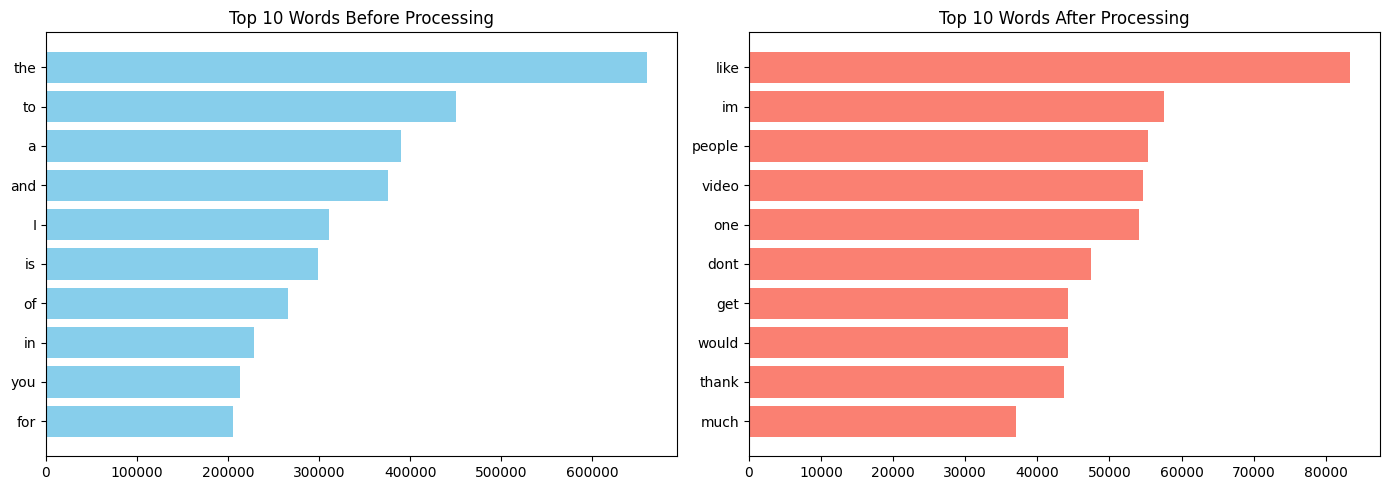

In [27]:
import matplotlib.pyplot as plt

before_words = dict(stats_before['top_10_words'])
after_words = dict(stats_after['top_10_words'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
axes[0].barh(list(before_words.keys()), list(before_words.values()), color='skyblue')
axes[0].set_title('Top 10 Words Before Processing')
axes[0].invert_yaxis()

# After
axes[1].barh(list(after_words.keys()), list(after_words.values()), color='salmon')
axes[1].set_title('Top 10 Words After Processing')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


Also this code block, This code block generates a bar chart that visually represents the reduction in word count at each stage of the text preprocessing pipeline. Using matplotlib, it first defines a dictionary `word_counts` that captures the number of words after each step starting from the raw text, then through lowercasing, special character removal, stopword removal, tokenization, and finally the fully cleaned text. The chart helps to clearly demonstrate the cumulative impact of each cleaning process on the dataset, making it easier to observe how unnecessary or noisy components were removed.

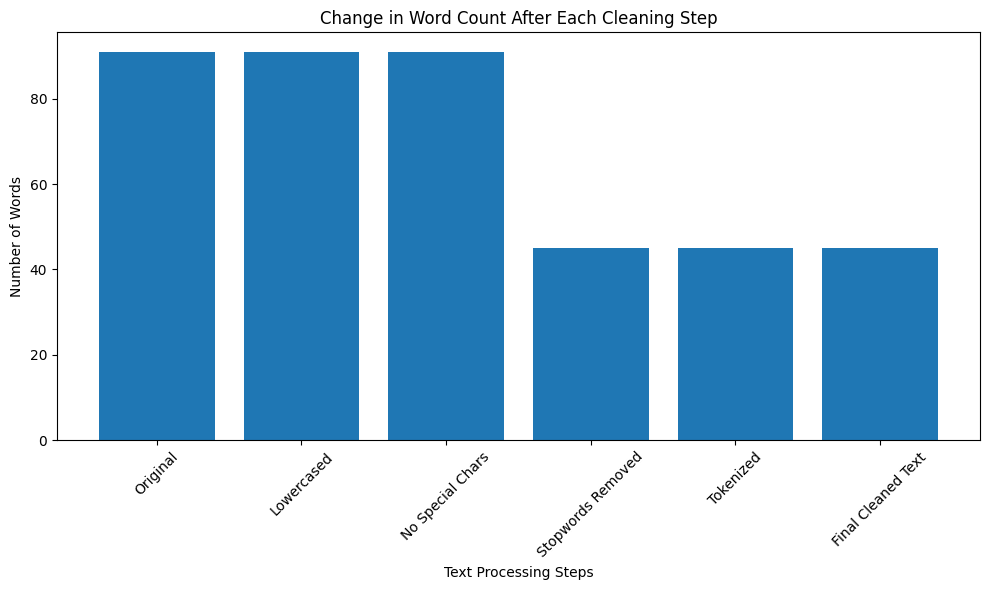

In [28]:
import matplotlib.pyplot as plt


word_counts = {
    'Original': len(raw_text.split()),
    'Lowercased': len(lowercased.split()),
    'No Special Chars': len(no_special_chars.split()),
    'Stopwords Removed': len(stopwords_removed.split()),
    'Tokenized': len(tokens),
    'Final Cleaned Text': len(cleaned_text.split())
}

plt.figure(figsize=(10, 6))
plt.bar(word_counts.keys(), word_counts.values())
plt.xlabel('Text Processing Steps')
plt.ylabel('Number of Words')
plt.title('Change in Word Count After Each Cleaning Step')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
